Cleaning decisions

- Missing values are kept as `NaN` rather than being guessed or filled in arbitrarily.
- A few clearly truncated brand names are standardized:
  - `Land` to `Land Rover`
  - `Aston` to `Aston Martin`
  - `Alfa` to `Alfa Romeo`
  - `smart` ro `Smart`
- Original columns are preserved, and new cleaned columns are added for analysis.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

DATA_PATH = Path("used_cars.csv")
OUTPUT_PATH = Path("cleaned_used_cars.csv")


## 1. Load the raw dataset

We begin by reading the original CSV file and previewing the first few rows.


In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Rows, columns: {df.shape}")
display(df.head())


## 2. Audit the raw data

This section checks:
- data types
- missing values
- percentage of missing values
- number of unique values
- exact duplicate rows


In [ ]:
audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    }
).sort_values(["missing_values", "n_unique"], ascending=[False, False])

print("Duplicate rows:", df.duplicated().sum())
display(audit)


### Key issues found

- `price` and `milage` are stored as text instead of numeric values.
- Some categorical columns contain placeholders such as `–` and `not supported`.
- `fuel_type`, `accident`, and `clean_title` contain missing values.
- A few brand names appear truncated and need standardization.


## 3. Clean the dataset

The cleaning steps below:
- standardize column names
- trim extra whitespace
- convert placeholders to missing values
- fix a few brand labels
- convert price and mileage into numeric fields
- create simple boolean helper columns
- remove exact duplicate rows


In [ ]:
clean = df.copy()

# Standardize column names
clean.columns = [c.strip().lower().replace(" ", "_") for c in clean.columns]

# Trim whitespace from text columns
for col in clean.select_dtypes(include="object").columns:
    clean[col] = clean[col].astype(str).str.strip()

# Restore true missing values created by astype(str)
clean = clean.replace({"nan": np.nan, "None": np.nan})

# Replace placeholder values with NaN
placeholders = ["–", "not supported", "N/A", ""]
clean = clean.replace(placeholders, np.nan)

# Standardize a few clearly truncated brand names
brand_map = {
    "Land": "Land Rover",
    "Aston": "Aston Martin",
    "Alfa": "Alfa Romeo",
    "smart": "Smart",
}
clean["brand"] = clean["brand"].replace(brand_map)

# Light text cleanup for color columns
for col in ["ext_col", "int_col"]:
    clean[col] = clean[col].str.replace(r"\.+$", "", regex=True).str.strip()

# Convert price to numeric
clean["price_usd"] = pd.to_numeric(
    clean["price"].replace(r"[\$,]", "", regex=True),
    errors="coerce",
)

# Convert milage to numeric mileage in miles
clean["mileage_mi"] = pd.to_numeric(
    clean["milage"].replace(r"[^0-9]", "", regex=True),
    errors="coerce",
)

# Create analysis-friendly flag columns
clean["clean_title_flag"] = clean["clean_title"].map({"Yes": True})
clean["accident_reported"] = clean["accident"].map(
    {
        "At least 1 accident or damage reported": True,
        "None reported": False,
    }
)

# Remove exact duplicate rows if any exist
clean = clean.drop_duplicates().reset_index(drop=True)

print(f"Cleaned rows, columns: {clean.shape}")
display(clean.head())


## 4. Validate the cleaned result

After cleaning, we re-check the dataset to confirm that the structure and newly created columns look correct.


In [5]:
clean_audit = pd.DataFrame(
    {
        "dtype": clean.dtypes.astype(str),
        "missing_values": clean.isna().sum(),
        "missing_percent": (clean.isna().mean() * 100).round(2),
        "n_unique": clean.nunique(dropna=True),
    }
).sort_values(["missing_values", "n_unique"], ascending=[False, False])

display(clean_audit)


,dtype,missing_values,missing_percent,n_unique
clean_title,object,596,14.87,1
clean_title_flag,object,596,14.87,1
fuel_type,object,217,5.41,5
int_col,object,133,3.32,153
accident,object,113,2.82,2
accident_reported,object,113,2.82,2
engine,object,45,1.12,1145
ext_col,object,15,0.37,318
transmission,object,4,0.10,61
milage,object,0,0.00,2818


In [6]:
comparison = pd.DataFrame(
    {
        "raw_price": df["price"].head(8),
        "clean_price_usd": clean["price_usd"].head(8),
        "raw_milage": df["milage"].head(8),
        "clean_mileage_mi": clean["mileage_mi"].head(8),
        "raw_brand": df["brand"].head(8),
        "clean_brand": clean["brand"].head(8),
    }
)

display(comparison)


,raw_price,clean_price_usd,raw_milage,clean_mileage_mi,raw_brand,clean_brand
0,"$10,300",10300,"51,000 mi.",51000,Ford,Ford
1,"$38,005",38005,"34,742 mi.",34742,Hyundai,Hyundai
2,"$54,598",54598,"22,372 mi.",22372,Lexus,Lexus
3,"$15,500",15500,"88,900 mi.",88900,INFINITI,INFINITI
4,"$34,999",34999,"9,835 mi.",9835,Audi,Audi
5,"$14,798",14798,"136,397 mi.",136397,Acura,Acura
6,"$31,000",31000,"84,000 mi.",84000,Audi,Audi
7,"$7,300",7300,"242,000 mi.",242000,BMW,BMW


## 5. Summary tables

These tables give a quick overview of the cleaned numeric columns and the most common brands in the dataset.


In [ ]:
summary_stats = clean[["model_year", "price_usd", "mileage_mi"]].describe().round(2)
display(summary_stats)

top_brands = (
    clean["brand"]
    .value_counts()
    .head(10)
    .rename_axis("brand")
    .reset_index(name="count")
)
display(top_brands)

avg_price_by_brand = (
    clean.groupby("brand", dropna=False)["price_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
    .rename_axis("brand")
    .reset_index(name="avg_price_usd")
)
display(avg_price_by_brand)


,model_year,price_usd,mileage_mi
count,4009.00,4009.00,4009.00
mean,2015.52,44553.19,64717.55
std,6.10,78710.64,52296.60
min,1974.00,2000.00,100.00
25%,2012.00,17200.00,23044.00
50%,2017.00,31000.00,52775.00
75%,2020.00,49990.00,94100.00
max,2024.00,2954083.00,405000.00


,brand,count
0,Ford,386
1,BMW,375
2,Mercedes-Benz,315
3,Chevrolet,292
4,Porsche,201
5,Audi,200
6,Toyota,199
7,Lexus,163
8,Jeep,143
9,Land Rover,130


,brand,avg_price_usd
0,Bugatti,1950995.00
1,Rolls-Royce,370992.73
2,Lamborghini,291233.85
3,Ferrari,243790.67
4,McLaren,213457.50
5,Maserati,140582.53
6,Bentley,137553.55
7,Aston Martin,115199.56
8,Lucid,101966.33
9,Rivian,93138.18


## 6. Quick visuals

These simple histograms help show the distribution of vehicle prices and mileage.


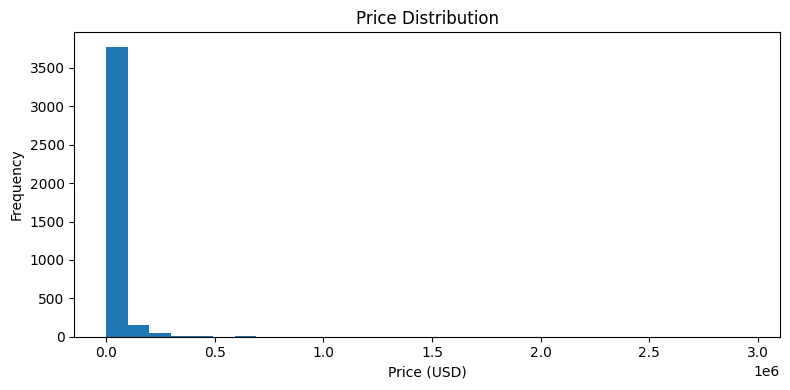

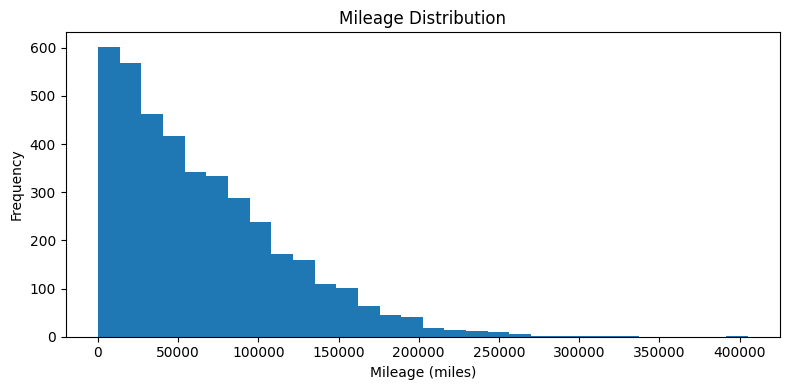

In [8]:
clean["price_usd"].plot(kind="hist", bins=30, figsize=(8, 4), title="Price Distribution")
plt.xlabel("Price (USD)")
plt.tight_layout()
plt.show()

clean["mileage_mi"].plot(kind="hist", bins=30, figsize=(8, 4), title="Mileage Distribution")
plt.xlabel("Mileage (miles)")
plt.tight_layout()
plt.show()


## 7. Save the cleaned dataset

Finally, we export the cleaned dataset so it can be used in later analysis or modeling.


In [ ]:
clean.to_csv(OUTPUT_PATH, index=False)
print(f"Saved cleaned file to: {OUTPUT_PATH.resolve()}")


## 8. Final cleaned columns

### Original columns retained
`brand`, `model`, `model_year`, `milage`, `fuel_type`, `engine`, `transmission`, `ext_col`, `int_col`, `accident`, `clean_title`, `price`

### New analysis-friendly columns
- `price_usd`
- `mileage_mi`
- `clean_title_flag`
- `accident_reported`

The cleaned dataset is now easier to analyze because important fields such as price and mileage are available in numeric form.
